In [45]:
%load_ext autoreload
%autoreload 2
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from finsler_embedding.disbm import *
from finsler_embedding.operators import *
from finsler_embedding.utils import get_bounds, get_grid_pts

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
N, K = 1000, 15
m = 2
eps_scale = .10


r = 0.1
p = 0.4
q = 1 - p - r

edges, dst_edges, community_labels, A = graph_info(p,q,r,K,N)

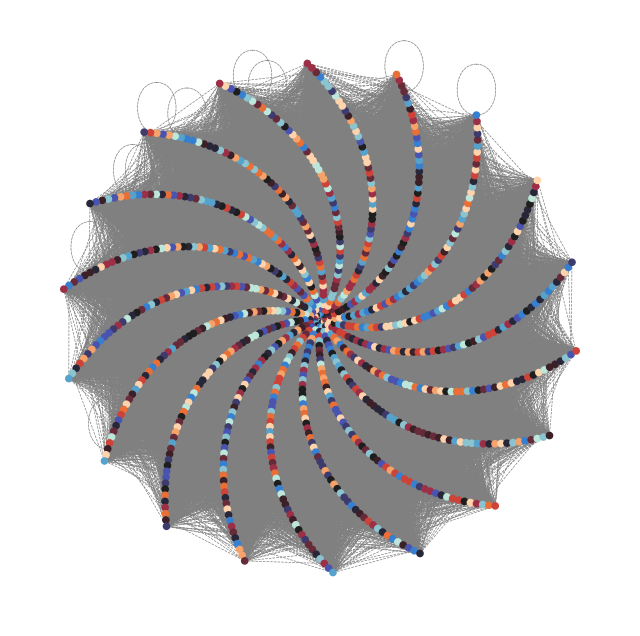

In [47]:
graph = nx.from_numpy_array(A.numpy())
cmap = sns.color_palette("icefire", as_cmap=True)
fig,ax = plt.subplots(figsize=(8,8))
nx.draw(graph, with_labels=False, node_color=community_labels.numpy(), cmap=cmap,pos=nx.spiral_layout(graph),node_size=20,edge_color='gray', width=0.5,style='dashed',ax=ax)
# fig.savefig("disbm_graph.pdf", dpi=300, bbox_inches='tight',pad_inches=0.)
# fig.savefig("disbm_graph.png", dpi=300, bbox_inches='tight',pad_inches=0.)  # replaced by disbm_graph.pdf below

In [48]:
epsilon = 1
W = apply_gaussian_kernel(edges, dst_edges, epsilon, N)

In [49]:
# Leading eigenvectors of L^s: SpectralEmbedding returns the eigenvectors of the random-walk
# Laplacian of the symmetric part of the theta-normalized kernel (theta = 1, as in randers_approximation)
W_theta_s, _ = get_W_thetas(W, get_Q_inv_theta(W, theta=1))
X_low = SpectralEmbedding(n_components=2, affinity='precomputed').fit_transform(W_theta_s.numpy())
X_low = torch.from_numpy(X_low).float()

In [ ]:
# Sampled DiSBM graph: nodes grouped by community on a circle (same colors, order and orientation as in
# the embedding), and a sample of the edges between neighboring communities, drawn as arcs with an
# arrowhead at their middle. Forward edges (k -> k+1, probability p) are light gray, backward edges
# (k -> k-1, probability q) are black; with the same curvature sign, the two directions bend to opposite
# sides of the cycle. Every community shows the same numbers of forward and backward edges, with the
# imbalance between p and q exaggerated for readability (here q > p: 1 forward for 4 backward).
import numpy as np

# Edges shown per community, exaggerating the imbalance: 4 in the dominant direction, 1 in the other
n_forward, n_backward = (4, 1) if p > q else (1, 4)
labels_np = community_labels.numpy()
mu = torch.stack([X_low[community_labels == k].mean(0) for k in range(K)]).numpy()
angles = np.arctan2(*(mu - mu.mean(0)).T[::-1])
orientation = np.sign(np.angle(np.exp(1j * (np.roll(angles, -1) - angles))).mean())  # +1: k -> k+1 counterclockwise
theta = angles[0] + orientation * 2 * np.pi * np.arange(K) / K
centers = np.stack([np.cos(theta), np.sin(theta)], axis=1)
rng = np.random.default_rng(0)
points = centers[labels_np] + 0.04 * rng.standard_normal((N, 2))

source, target = (t.numpy() for t in A.nonzero(as_tuple=True))
forward = labels_np[target] == (labels_np[source] + 1) % K
backward = labels_np[target] == (labels_np[source] - 1) % K
shown = []
for k in range(K):
    from_k = labels_np[source] == k
    shown += list(rng.choice(np.flatnonzero(from_k & forward), size=n_forward, replace=False))
    shown += list(rng.choice(np.flatnonzero(from_k & backward), size=n_backward, replace=False))

def arc_points(p0, p1, rad, n=30):
    # Quadratic Bezier with the control point of matplotlib's "arc3" connection style
    d = p1 - p0
    control = (p0 + p1) / 2 + rad * np.array([d[1], -d[0]])
    t = np.linspace(0, 1, n)[:, None]
    return (1 - t) ** 2 * p0 + 2 * (1 - t) * t * control + t**2 * p1


fig, ax = plt.subplots(figsize=(8, 8))
for e in shown:
    color = "#a3a29d" if forward[e] else "#1a1a19"
    curve = arc_points(points[source[e]], points[target[e]], rad=0.45)
    ax.plot(curve[:, 0], curve[:, 1], color=color, linewidth=1.3, alpha=0.85, zorder=1, solid_capstyle="round")
    # Small arrowhead at the middle of the edge, pointing to its target
    mid = len(curve) // 2
    ax.annotate("", xy=curve[mid + 1], xytext=curve[mid - 1], zorder=1,
                arrowprops=dict(arrowstyle="-|>,head_length=0.8,head_width=0.4", color=color, linewidth=0,
                                shrinkA=0, shrinkB=0, mutation_scale=11))
ax.scatter(points[:, 0], points[:, 1], c=labels_np, cmap=cmap, s=25, zorder=2)
ax.set_aspect("equal")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.axis("off")
fig.savefig("disbm_graph.pdf", bbox_inches="tight", pad_inches=0.)
plt.show()

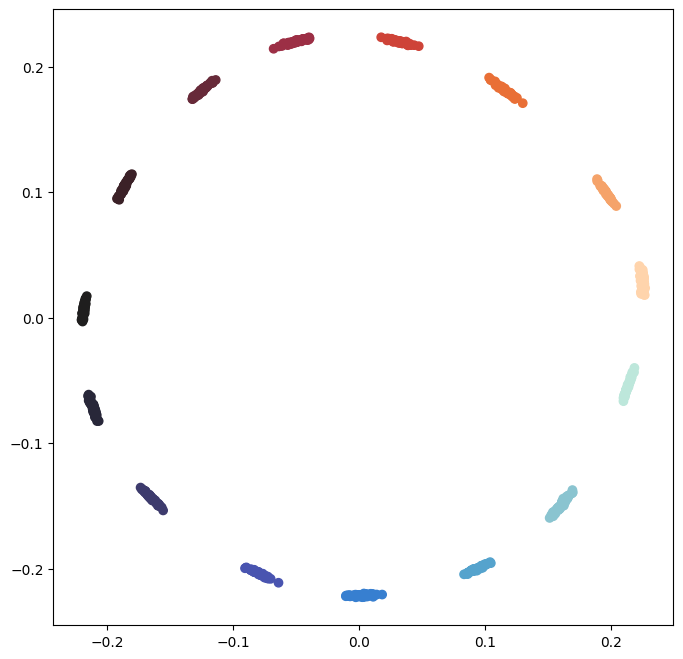

In [50]:
plt.figure(figsize=(8, 8))
plt.scatter(X_low[:,0].cpu().numpy(), X_low[:,1].cpu().numpy(), c=community_labels.cpu().numpy(), cmap=cmap)

In [51]:
results = randers_approximation(W, epsilon, m=m,X_low=X_low)
V = results["V"]
V_normed = V / (results["c_norm_sq"].sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

In [52]:
# Sort by x coords for display
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone()
V_plt = V[idx].clone()
unit_V_plt = unit_V[idx].clone()
community_labels_plt = community_labels[idx].clone()

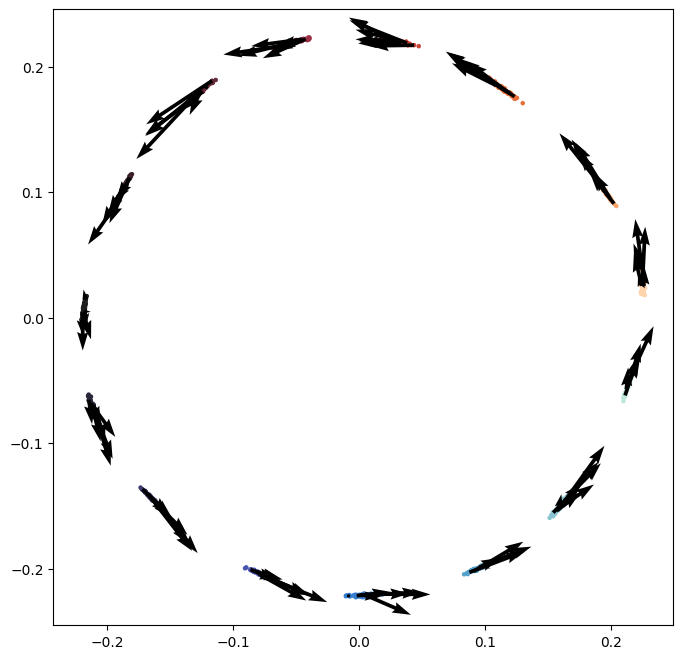

In [53]:
plt.figure(figsize=(8, 8))
cbar = plt.scatter(
    X_low_plt[:, 0], X_low_plt[:, 1], c=community_labels_plt, cmap=cmap,s=5
)
skip=10
plt.quiver(
    X_low_plt[::skip, 0],
    X_low_plt[::skip, 1],
    # unit_V_plt[::skip, 0],
    # unit_V_plt[::skip, 1],
    V_plt[::skip, 0],
    V_plt[::skip, 1],
    color="black",
    scale=0.3,
    angles="xy",
    scale_units="xy",
)

In [54]:
model, loss_list = interpolate_V(X_low, V, dim=m)

Loss: 0.0000: 100%|██████████| 500/500 [00:01<00:00, 340.30it/s]


In [ ]:
bounds = get_bounds(X_low, margin=0.05)
grid_points = get_grid_pts(bounds, n_pts=20)
width = (bounds[1] - bounds[0]).item()

# Only draw arrows close to the data: elsewhere the interpolating network extrapolates freely
# grid_points = grid_points[torch.cdist(grid_points, X_low).min(dim=1).values < 0.15 * width]

V_grid = model(grid_points).detach()
V_grid_unit = V_grid / (V_grid.norm(dim=1, keepdim=True) + 1e-12)

plt.figure(figsize=(8, 8))
plt.scatter(X_low[:, 0], X_low[:, 1], c=community_labels, cmap=cmap)
plt.quiver(
    grid_points[:, 0],
    grid_points[:, 1],
    V_grid_unit[:, 0],
    V_grid_unit[:, 1],
    color="black",
    scale=1 / (0.04 * width),  # arrow length: 4% of the plot width
    # scale = 2000, # Old behavior
    angles="xy",
    scale_units="xy",
)
plt.xlim(bounds[0], bounds[1])
plt.ylim(bounds[2], bounds[3])
plt.tight_layout()
# plt.axis("equal")
plt.axis("off")
plt.savefig("disbm_vector_field.pdf", dpi=300, bbox_inches='tight',pad_inches=0.)
plt.show()